In [1]:
import numpy as np
import scipy.sparse as sp

# Load TF-IDF features
X = sp.load_npz("../outputs/tfidf_features.npz")

# Load labels
y = np.load("../outputs/labels.npy")

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (5167, 5000)
Labels shape: (5167,)


In [2]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (4133, 5000)
Testing features: (1034, 5000)
Training labels: (4133,)
Testing labels: (1034,)


In [3]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [4]:
# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions completed successfully!")
print("Number of predictions:", len(y_pred_logistic))

Predictions completed successfully!
Number of predictions: 1034


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Evaluation")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Logistic Regression Evaluation
-----------------------------------
Accuracy : 0.9681
Precision: 0.9900
Recall   : 0.7557
F1-Score : 0.8571


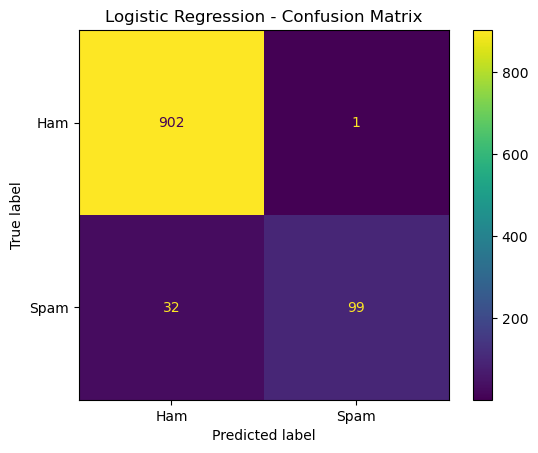

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [7]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes trained successfully!")

Multinomial Naive Bayes trained successfully!


In [8]:
# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes predictions completed successfully!")
print("Number of predictions:", len(y_pred_nb))

Naive Bayes predictions completed successfully!
Number of predictions: 1034


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Evaluation")
print("-" * 40)
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

Multinomial Naive Bayes Evaluation
----------------------------------------
Accuracy : 0.9797
Precision: 1.0000
Recall   : 0.8397
F1-Score : 0.9129


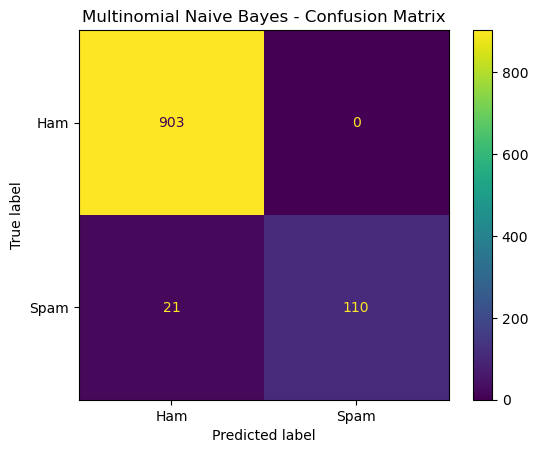

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Display confusion matrix
disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Ham", "Spam"]
)

disp_nb.plot()
plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.show()

In [11]:
from sklearn.svm import LinearSVC

# Create the model
svm_model = LinearSVC(
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

print("Linear SVM trained successfully!")

Linear SVM trained successfully!


In [12]:
# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

print("Linear SVM predictions completed successfully!")
print("Number of predictions:", len(y_pred_svm))

Linear SVM predictions completed successfully!
Number of predictions: 1034


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Linear SVM Evaluation")
print("-" * 30)
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

Linear SVM Evaluation
------------------------------
Accuracy : 0.9865
Precision: 0.9835
Recall   : 0.9084
F1-Score : 0.9444


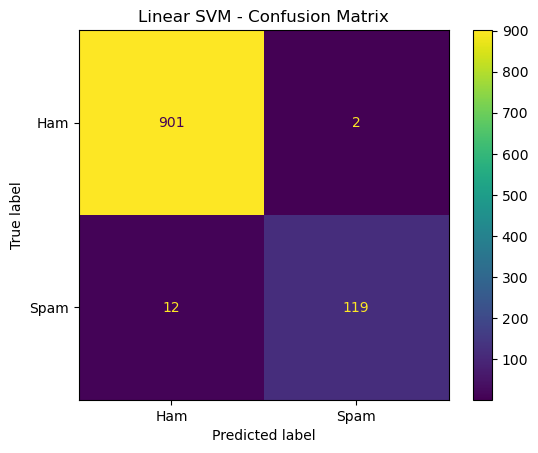

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Display confusion matrix
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Ham", "Spam"]
)

disp_svm.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [17]:
import pandas as pd

# Create a comparison table for all models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_svm
    ],
    "F1-Score": [
        f1,
        f1_nb,
        f1_svm
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.968085,0.990000,0.755725,0.857143
1,Multinomial Naive Bayes,0.979691,1.000000,0.839695,0.912863
2,Linear SVM,0.986460,0.983471,0.908397,0.944444


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Create the base SVM model
svm_tuning_model = LinearSVC(random_state=42)

# Define the parameters we want to test
param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

# Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=svm_tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Train using training data only
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully!")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", round(grid_search.best_score_, 4))

Hyperparameter tuning completed successfully!
Best Parameters: {'C': 1, 'class_weight': None}
Best Cross-Validation F1-Score: 0.9368


In [19]:
# Get the best tuned SVM model
best_svm_model = grid_search.best_estimator_

print("Best SVM model selected successfully!")
print("Best Parameters:", grid_search.best_params_)

Best SVM model selected successfully!
Best Parameters: {'C': 1, 'class_weight': None}


In [20]:
# Make predictions using the tuned SVM
y_pred_tuned_svm = best_svm_model.predict(X_test)

print("Tuned SVM predictions completed successfully!")
print("Number of predictions:", len(y_pred_tuned_svm))

Tuned SVM predictions completed successfully!
Number of predictions: 1034


In [21]:
# Evaluate the tuned SVM

accuracy_tuned_svm = accuracy_score(y_test, y_pred_tuned_svm)
precision_tuned_svm = precision_score(y_test, y_pred_tuned_svm)
recall_tuned_svm = recall_score(y_test, y_pred_tuned_svm)
f1_tuned_svm = f1_score(y_test, y_pred_tuned_svm)

print("Tuned Linear SVM Evaluation")
print("-" * 35)
print(f"Accuracy : {accuracy_tuned_svm:.4f}")
print(f"Precision: {precision_tuned_svm:.4f}")
print(f"Recall   : {recall_tuned_svm:.4f}")
print(f"F1-Score : {f1_tuned_svm:.4f}")

Tuned Linear SVM Evaluation
-----------------------------------
Accuracy : 0.9865
Precision: 0.9835
Recall   : 0.9084
F1-Score : 0.9444


In [22]:
# Add the tuned SVM results to the comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Tuned Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_svm,
        accuracy_tuned_svm
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_svm,
        precision_tuned_svm
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_svm,
        recall_tuned_svm
    ],
    "F1-Score": [
        f1,
        f1_nb,
        f1_svm,
        f1_tuned_svm
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.968085,0.990000,0.755725,0.857143
1,Multinomial Naive Bayes,0.979691,1.000000,0.839695,0.912863
2,Linear SVM,0.986460,0.983471,0.908397,0.944444
3,Tuned Linear SVM,0.986460,0.983471,0.908397,0.944444


In [ ]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LinearSVC                type                      <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MultinomialNB            ABCMeta                   <class 'sklearn.naive_bayes.MultinomialNB'>
X                        csr_matrix                <Compressed Sparse Row sp<...>2144)	0.49698522946730517
X_test                   csr_matrix                <Compressed Sparse Row sp<...> 1052)	0.3606875684707542
X_train                  csr_matrix                <Compressed Sparse Row sp<...>2999)	0.40086071191192246
accuracy                 float                   

In [ ]:
print(X.shape)

(5167, 5000)


In [ ]:
print(X.shape)
print(type(X))

(5167, 5000)
<class 'scipy.sparse._csr.csr_matrix'>


In [27]:
import joblib

joblib.dump(best_svm_model, "../outputs/best_svm_model.pkl")

print("Best SVM model saved successfully!")

Best SVM model saved successfully!


In [28]:
import os

print("TF-IDF vectorizer exists:", os.path.exists("../outputs/tfidf_vectorizer.pkl"))
print("Best SVM model exists:", os.path.exists("../outputs/best_svm_model.pkl"))

TF-IDF vectorizer exists: True
Best SVM model exists: True


In [29]:
import joblib

# Load the saved model and TF-IDF vectorizer
model = joblib.load("../outputs/best_svm_model.pkl")
tfidf = joblib.load("../outputs/tfidf_vectorizer.pkl")

# Test message
message = ["Congratulations! You won a free prize!"]

# Convert the message to TF-IDF features
message_tfidf = tfidf.transform(message)

# Predict
prediction = model.predict(message_tfidf)

print("Prediction:", prediction[0])

Prediction: 1


In [30]:
test_messages = [
    "Congratulations! You won a free prize!",
    "Hey, are we still meeting tomorrow?"
]

test_tfidf = tfidf.transform(test_messages)
predictions = model.predict(test_tfidf)

for message, prediction in zip(test_messages, predictions):
    print("Message:", message)
    print("Prediction:", prediction)
    print("-" * 50)

Message: Congratulations! You won a free prize!
Prediction: 1
--------------------------------------------------
Message: Hey, are we still meeting tomorrow?
Prediction: 0
--------------------------------------------------
